In [6]:
!pip install imbalanced-learn --quiet

In [1]:
#manipulação
import pandas as pd
import numpy as np
#visualização
import matplotlib.pyplot as plt
import seaborn as sns
#modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# treino
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from imblearn.under_sampling import RandomUnderSampler
#selecao de features
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
#resultados
from sklearn.metrics import accuracy_score, classification_report, classification_report, confusion_matrix

## Pré processamento

Feito na base toda com as 5000000 de instancias

In [ ]:
df_full = pd.read_csv('./data/DrDoS_DNS.csv')

FileNotFoundError: [Errno 2] No such file or directory: './data/DrDoS_DNS.csv'

In [ ]:
df_full.shape

NameError: name 'df_full' is not defined

In [ ]:
df_remove = df_full.drop(columns=[
    'Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
    ' Destination IP', ' Destination Port', ' Timestamp', ' Bwd PSH Flags',
    ' Fwd URG Flags', ' Bwd URG Flags'])

NameError: name 'df_full' is not defined

In [ ]:
is_attack = {'DrDoS_DNS': 1, 'BENIGN': 0}
df_remove['is_attack'] = df_remove[' Label'].map(is_attack)
df_remove = df_remove.drop(' Label', axis=1)
df_remove.shape


NameError: name 'df_remove' is not defined

In [ ]:
df_benign.shape

NameError: name 'df_benign' is not defined

In [ ]:
df_benign = df_remove[df_remove['is_attack']==1]
df_benign.to_csv('./data/attack.csv', index=False)

NameError: name 'df_remove' is not defined

In [3]:
df_attack = pd.read_csv('./data/attack.csv')
df_attack.columns = df_attack.columns.str.strip()
df_attack.replace([np.inf, -np.inf], np.nan, inplace=True)
df_attack.shape

/tmp/ipykernel_40405/1757050657.py:1: DtypeWarning: Columns (0: SimillarHTTP) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attack = pd.read_csv('./data/attack.csv')


(5071011, 78)

In [4]:
df_attack_unico = df_attack.drop(columns=['SimillarHTTP']).dropna()
df_attack_unico = df_attack.loc[df_attack_unico.drop_duplicates().index]

In [5]:
print(f'Total:          {len(df_attack):,}')
print(f'Após dropna:    {len(df_attack.drop(columns=["SimillarHTTP"]).dropna()):,}')
print(f'Únicos:         {len(df_attack_unico):,}')

Total:          5,071,011
Após dropna:    4,908,665
Únicos:         108,211


In [53]:
df_attack_unico.isnull().sum().sort_values(ascending=False)
df_attack_unico.drop('SimillarHTTP', axis=1, inplace=True)

In [ ]:
df_attack_unico.to_csv('./data/attack_uniq.csv', index=False)

In [18]:
df_attack_unico = pd.read_csv('./data/attack_uniq.csv')
df_attack_unico.shape

(108211, 77)

In [9]:
# Remove duplicatas e NaN, depois amostra
df_attack_limpo = df_attack.drop(columns=['SimillarHTTP']).dropna().drop_duplicates()
df_attack_limpo.replace([np.inf, -np.inf], np.nan, inplace=True)


NameError: name 'df_attack' is not defined

In [10]:
df_attack_limpo.isnull().sum().sort_values(ascending=False)

NameError: name 'df_attack_limpo' is not defined

In [12]:
df_benign = pd.read_csv('./data/benign.csv')
df_benign.replace([np.inf, -np.inf], np.nan, inplace=True)
df_benign.shape

(3402, 78)

In [13]:
df_benign.columns = df_benign.columns.str.strip()
df_benign = df_benign.drop('SimillarHTTP', axis=1)
df_benign.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
      

In [14]:
df_benign.duplicated().sum()

np.int64(326)

In [15]:
df_benign = df_benign.drop_duplicates()

In [16]:
df_benign.isnull().sum().sort_values(ascending=False)

Flow Bytes/s         36
Flow Packets/s       36
Total Fwd Packets     0
Flow Duration         0
Protocol              0
                     ..
Idle Std              0
Idle Max              0
Idle Min              0
Inbound               0
is_attack             0
Length: 77, dtype: int64

In [17]:
df_benign.dropna(inplace=True)
df_benign.isnull().sum().sort_values(ascending=False)

Protocol                       0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Std                       0
Idle Max                       0
Idle Min                       0
Inbound                        0
is_attack                      0
Length: 77, dtype: int64

In [20]:
df_final = pd.concat([df_attack_unico, df_benign], ignore_index=True)
df_final.shape

(111251, 77)

In [21]:
df_final.to_csv('./data/final.csv', index=False)

## Base de dados com o sample

In [22]:
df_final = pd.read_csv('./data/final.csv')

In [23]:
df_final['is_attack'].value_counts()

is_attack
1    108211
0      3040
Name: count, dtype: int64

In [24]:
df_final.head(10)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,is_attack
0,17,28415,97,0,42680.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
1,17,2,2,0,880.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
2,17,48549,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
3,17,48337,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
4,17,32026,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
5,17,46469,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
6,17,31201,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
7,17,50453,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
8,17,31008,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
9,17,30143,200,0,88000.0,0.0,440.0,440.0,440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1


In [25]:
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,is_attack
0,17,28415,97,0,42680.0,0.0,440.0,440.0,440.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1,1
1,17,2,2,0,880.0,0.0,440.0,440.0,440.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0,1
2,17,48549,200,0,88000.0,0.0,440.0,440.0,440.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1,1
3,17,48337,200,0,88000.0,0.0,440.0,440.0,440.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1,1
4,17,32026,200,0,88000.0,0.0,440.0,440.0,440.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111246,0,19029778,12,0,0.0,0.0,0.0,0.0,0.0,0.000000,...,6.0,0.0,6.0,6.0,9514879.5,8402.549881,9520821.0,9508938.0,0,0
111247,6,171239,1,1,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0,0
111248,6,221,1,2,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1,0
111249,6,62253,4,2,92.0,92.0,46.0,0.0,23.0,26.558112,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0,0


In [26]:
df_final.isnull().sum().sort_values(ascending=False).head(20)

Protocol                       0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
dtype: int64

In [27]:
df_final['Inbound'].value_counts()

Inbound
1    108067
0      3184
Name: count, dtype: int64

In [28]:
X = df_final.drop(['is_attack'], axis=1)
y = df_final['is_attack']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

In [29]:
X_train_res.shape, X_test.shape, y_train_res.shape, y_test.shape

((4864, 76), (22251, 76), (4864,), (22251,))

### Seleção de features

In [30]:
mi_scores = mutual_info_classif(X_train_res, y_train_res, random_state=42)

mi_series = pd.Series(mi_scores, index=X_train_res.columns).sort_values(ascending=False)
mi_series

Flow Bytes/s             0.593188
Min Packet Length        0.592294
Fwd Packet Length Min    0.590922
Max Packet Length        0.550371
Average Packet Size      0.545332
                           ...   
SYN Flag Count           0.000000
FIN Flag Count           0.000000
Fwd Avg Bytes/Bulk       0.000000
ECE Flag Count           0.000000
Fwd Avg Packets/Bulk     0.000000
Length: 76, dtype: float64

In [12]:
mi_series.to_csv('./data/feature_importance.csv')

In [31]:
features = mi_series[mi_series>0.5].index
features

Index(['Flow Bytes/s', 'Min Packet Length', 'Fwd Packet Length Min',
       'Max Packet Length', 'Average Packet Size', 'Packet Length Mean',
       'Fwd Packet Length Mean', 'Avg Fwd Segment Size',
       'Fwd Packet Length Max', 'Subflow Fwd Bytes',
       'Total Length of Fwd Packets'],
      dtype='str')

In [32]:
features.shape

(11,)

In [33]:
X_train_final = X_train_res[features]
X_test_final = X_test[features]

### Normalização dos dados

In [34]:
# para os modelo de KNN e regressão logistica deve ser normalizado as escalas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

## Baseline

In [35]:
X = df_final.drop(['is_attack'], axis=1)
y = df_final['is_attack']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_base.shape, X_test_base.shape, y_train_base.shape, y_test_base.shape


((89000, 76), (22251, 76), (89000,), (22251,))

In [67]:
log_reg_base = LogisticRegression(max_iter=1000)
log_reg_base.fit(X_train_base, y_train_base)
y_pred_base_lr = log_reg_base.predict(X_test_base)
print(classification_report(y_test_base, y_pred_base_lr))

              precision    recall  f1-score   support

           0       0.67      0.44      0.53       598
           1       0.98      0.99      0.99     21653

    accuracy                           0.98     22251
   macro avg       0.83      0.72      0.76     22251
weighted avg       0.98      0.98      0.98     22251



/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


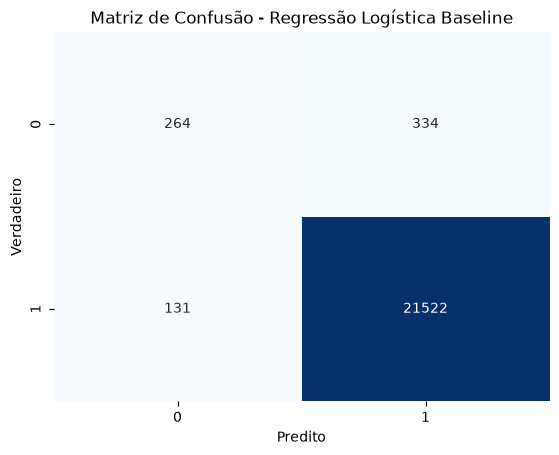

In [69]:
cm_log_reg_base = confusion_matrix(y_test_base, y_pred_base_lr)
sns.heatmap(cm_log_reg_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Regressão Logística Baseline')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

In [70]:
knn_base= KNeighborsClassifier()
knn_base.fit(X_train_base, y_train_base)
y_pred_base_knn = knn_base.predict(X_test_base)
print(classification_report(y_test_base, y_pred_base_knn))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93       598
           1       1.00      1.00      1.00     21653

    accuracy                           1.00     22251
   macro avg       0.98      0.95      0.97     22251
weighted avg       1.00      1.00      1.00     22251



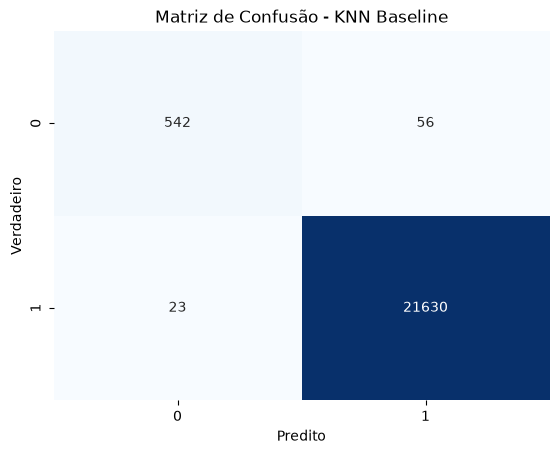

In [39]:
cm_knn_base = confusion_matrix(y_test_base, y_pred_base_knn)
sns.heatmap(cm_knn_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - KNN Baseline')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

In [40]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_base, y_train_base)
y_pred_base_dt = dt_base.predict(X_test_base)
print(classification_report(y_test_base, y_pred_base_dt))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       598
           1       1.00      1.00      1.00     21653

    accuracy                           1.00     22251
   macro avg       1.00      0.99      0.99     22251
weighted avg       1.00      1.00      1.00     22251



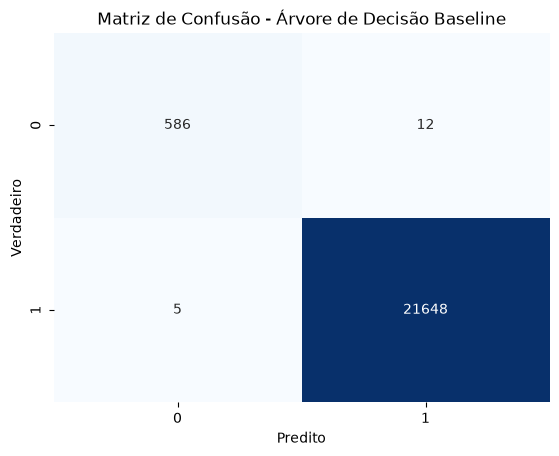

In [41]:
cm_dt_base = confusion_matrix(y_test_base, y_pred_base_dt)
sns.heatmap(cm_dt_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Árvore de Decisão Baseline')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

## Aplicação do método

### Regressão Logistica

In [42]:
# Configuração do Grid Search para Regressão Logística
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

In [43]:
log_reg = LogisticRegression()

In [44]:
# GridSearchCV com CV=10
grid_search = GridSearchCV(log_reg, param_grid, cv=10, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_res)
# Melhores parâmetros e modelo
best_model = grid_search.best_estimator_
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor pontuação de validação cruzada: {grid_search.best_score_}")

/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

Melhores parâmetros: {'C': 100, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Melhor pontuação de validação cruzada: 0.9658420600461278


In [45]:
# Predições e Métricas
y_pred = best_model.predict(X_test_scaled)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))



Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.32      0.99      0.48       608
           1       1.00      0.94      0.97     21643

    accuracy                           0.94     22251
   macro avg       0.66      0.97      0.72     22251
weighted avg       0.98      0.94      0.96     22251



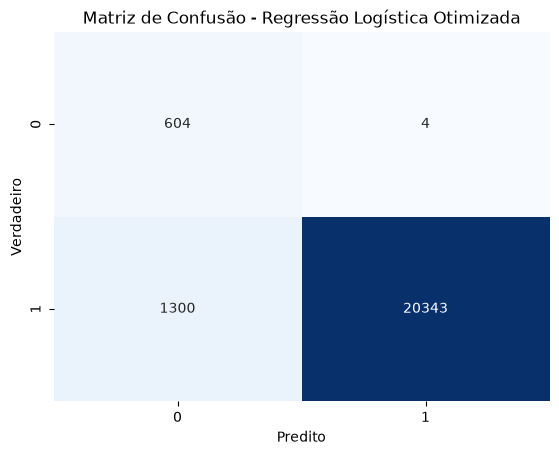

In [46]:
cm_log_reg = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Regressão Logística Otimizada')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

### KNN

In [47]:
# Configuração do Grid Search para KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


In [48]:
knn = KNeighborsClassifier()

# GridSearchCV com CV=10
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=10, scoring='f1_macro', n_jobs=-1)
grid_search_knn.fit(X_train_scaled, y_train_res)

# Melhores parâmetros e modelo
best_knn = grid_search_knn.best_estimator_
print(f"Melhores parâmetros KNN: {grid_search_knn.best_params_}")
print(f"Melhor pontuação (F1-Macro): {grid_search_knn.best_score_:.4f}")


Melhores parâmetros KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Melhor pontuação (F1-Macro): 0.9908


In [49]:
#Predições e Métricas
y_pred_knn = best_knn.predict(X_test_scaled)
print("\nRelatório de Classificação (KNN):")
print(classification_report(y_test, y_pred_knn))


Relatório de Classificação (KNN):
              precision    recall  f1-score   support

           0       0.69      1.00      0.81       608
           1       1.00      0.99      0.99     21643

    accuracy                           0.99     22251
   macro avg       0.84      0.99      0.90     22251
weighted avg       0.99      0.99      0.99     22251



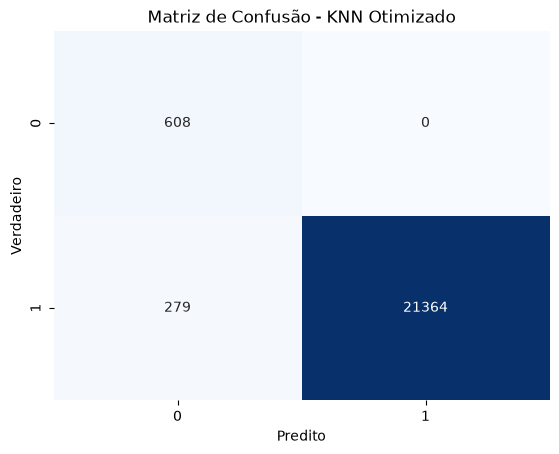

In [50]:
cm_best_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_best_knn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - KNN Otimizado')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

### Árvore de decisão

In [51]:
# Configuração do Grid Search para Árvore de Decisão
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}


In [52]:
dt = DecisionTreeClassifier(random_state=42)

# GridSearchCV com CV=10
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=10, scoring='f1_macro', n_jobs=-1)
grid_search_dt.fit(X_train_final, y_train_res)

# Melhores parâmetros e modelo
best_dt = grid_search_dt.best_estimator_
print(f"Melhores parâmetros Árvore de Decisão: {grid_search_dt.best_params_}")
print(f"Melhor pontuação (F1-Macro): {grid_search_dt.best_score_:.4f}")

Melhores parâmetros Árvore de Decisão: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor pontuação (F1-Macro): 0.9916


In [53]:
# Predições e Métricas
y_pred_dt = best_dt.predict(X_test_final)
print("\nRelatório de Classificação (Árvore de Decisão):")
print(classification_report(y_test, y_pred_dt))


Relatório de Classificação (Árvore de Decisão):
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       608
           1       1.00      0.99      0.99     21643

    accuracy                           0.99     22251
   macro avg       0.85      0.99      0.91     22251
weighted avg       0.99      0.99      0.99     22251



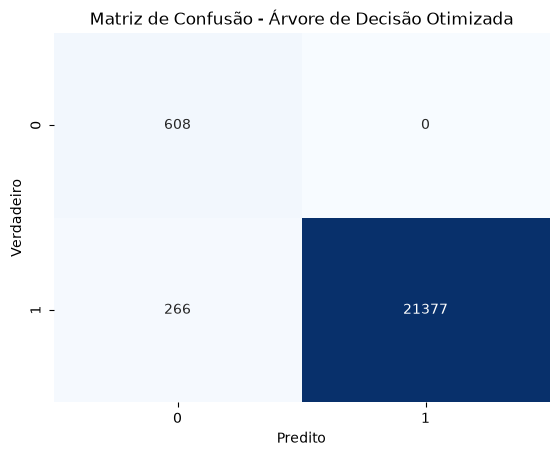

In [54]:
cm_best_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_best_dt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Árvore de Decisão Otimizada')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

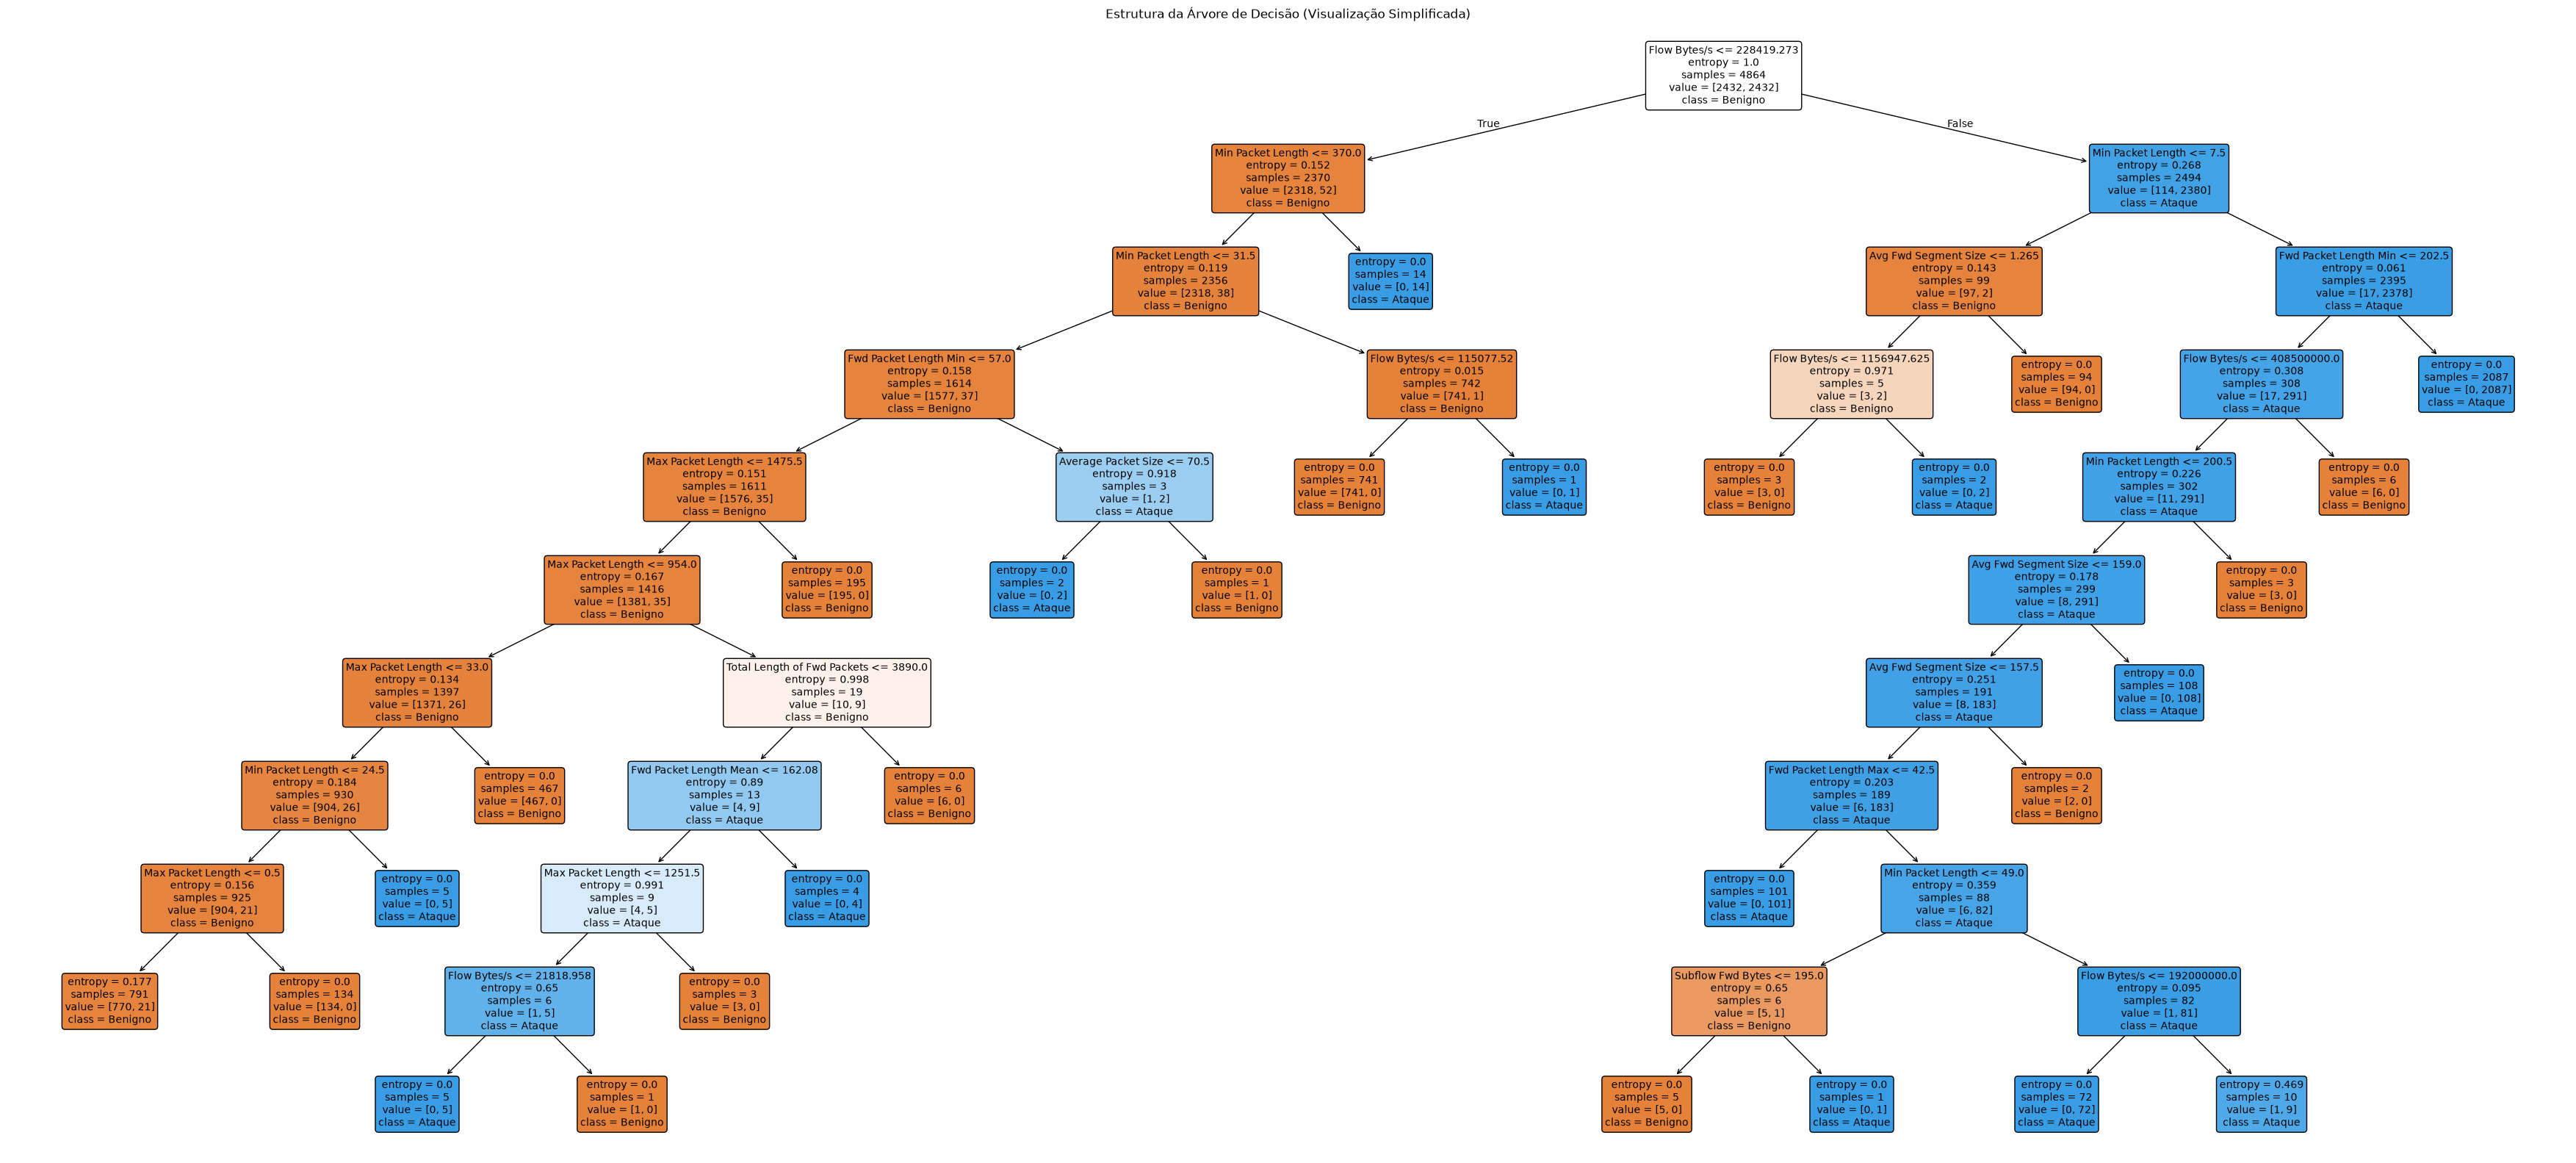

In [55]:
from sklearn.tree import plot_tree
# 3. Visualização da Árvore de Decisão (Interpretabilidade Direta)
plt.figure(figsize=(45, 20))
plot_tree(best_dt,
          feature_names=features,
          class_names=['Benigno', 'Ataque'],
          filled=True,
          rounded=True,
          fontsize=10,)
          # max_depth=3) # Limitamos a visualização para facilitar a leitura
plt.title("Estrutura da Árvore de Decisão (Visualização Simplificada)")
plt.show()

In [56]:
from sklearn.tree import export_text

regras = export_text(best_dt, feature_names=features)
print(regras)

|--- Flow Bytes/s <= 228419.27
|   |--- Min Packet Length <= 370.00
|   |   |--- Min Packet Length <= 31.50
|   |   |   |--- Fwd Packet Length Min <= 57.00
|   |   |   |   |--- Max Packet Length <= 1475.50
|   |   |   |   |   |--- Max Packet Length <= 954.00
|   |   |   |   |   |   |--- Max Packet Length <= 33.00
|   |   |   |   |   |   |   |--- Min Packet Length <= 24.50
|   |   |   |   |   |   |   |   |--- Max Packet Length <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- Max Packet Length >  0.50
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Min Packet Length >  24.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Max Packet Length >  33.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Max Packet Length >  954.00
|   |   |   |   |   |   |--- Total Length of Fwd Packets <= 3890.00
|   |   |   |   |   |   |   |--- Fwd Packet Length Mean <= 162.08
|   |   

### Validação com teste t

In [57]:
from scipy import stats

# Extrair scores por fold de cada modelo
lr_fold_scores  = [grid_search.cv_results_[f'split{i}_test_score'][grid_search.best_index_] for i in range(10)]
knn_fold_scores = [grid_search_knn.cv_results_[f'split{i}_test_score'][grid_search_knn.best_index_] for i in range(10)]
dt_fold_scores  = [grid_search_dt.cv_results_[f'split{i}_test_score'][grid_search_dt.best_index_] for i in range(10)]

# Testes pareados entre os modelos
t_lr_knn, p_lr_knn = stats.ttest_rel(lr_fold_scores, knn_fold_scores)
t_lr_dt,  p_lr_dt  = stats.ttest_rel(lr_fold_scores, dt_fold_scores)
t_knn_dt, p_knn_dt = stats.ttest_rel(knn_fold_scores, dt_fold_scores)

print(f"LR vs KNN: t={t_lr_knn:.4f}, p={p_lr_knn:.4f}")
print(f"LR vs DT:  t={t_lr_dt:.4f},  p={p_lr_dt:.4f}")
print(f"KNN vs DT: t={t_knn_dt:.4f}, p={p_knn_dt:.4f}")

LR vs KNN: t=-9.3765, p=0.0000
LR vs DT:  t=-9.0554,  p=0.0000
KNN vs DT: t=-0.6650, p=0.5227


O p-valor é extremamente baixo (0.0009<0.05). Isso significa que existe uma diferença estatisticamente significativa entre a Regressão Logística e o KNN.
KNN é melhor que LR

O p-valor é menor que 0,05 sendo 0.0001. A diferença é altamente significativa. DT é melhor que LR

O p-valor é maior que 0,05. Não há diferença estatisticamente significativa entre o KNN e a Árvore de Decisão

## Comparações

In [58]:
# Complexidade dos modelos — quanto menor, mais interpretável
print("=== COMPLEXIDADE DOS MODELOS ===\n")

# DT
print(f"Árvore de Decisão:")
print(f"  Profundidade:       {best_dt.get_depth()}")
print(f"  Número de nós:      {best_dt.tree_.node_count}")
print(f"  Número de folhas:   {best_dt.get_n_leaves()}")
print(f"  Features usadas:    {(best_dt.feature_importances_ > 0).sum()} de {len(features)}")

# LR
coef = best_model.coef_[0]
print(f"\nRegressão Logística:")
print(f"  Coeficientes não-zero: {(coef != 0).sum()} de {len(coef)}")
print(f"  Magnitude máxima:      {np.abs(coef).max():.3f} ({features[np.abs(coef).argmax()]})")
print(f"  Magnitude mínima:      {np.abs(coef).min():.3f}")
print(f"  Razão max/min:         {np.abs(coef).max()/np.abs(coef[coef!=0]).min():.1f}x")

# KNN
print(f"\nKNN:")
print(f"  k vizinhos:   {best_knn.n_neighbors}")
print(f"  Métrica:      {best_knn.metric}")
print(f"  Pesos:        {best_knn.weights}")
print(f"  Interpretabilidade: local (por instância)")

=== COMPLEXIDADE DOS MODELOS ===

Árvore de Decisão:
  Profundidade:       10
  Número de nós:      55
  Número de folhas:   28
  Features usadas:    10 de 11

Regressão Logística:
  Coeficientes não-zero: 11 de 11
  Magnitude máxima:      45.245 (Packet Length Mean)
  Magnitude mínima:      2.227
  Razão max/min:         20.3x

KNN:
  k vizinhos:   3
  Métrica:      manhattan
  Pesos:        distance
  Interpretabilidade: local (por instância)


Shape: (30, 11)


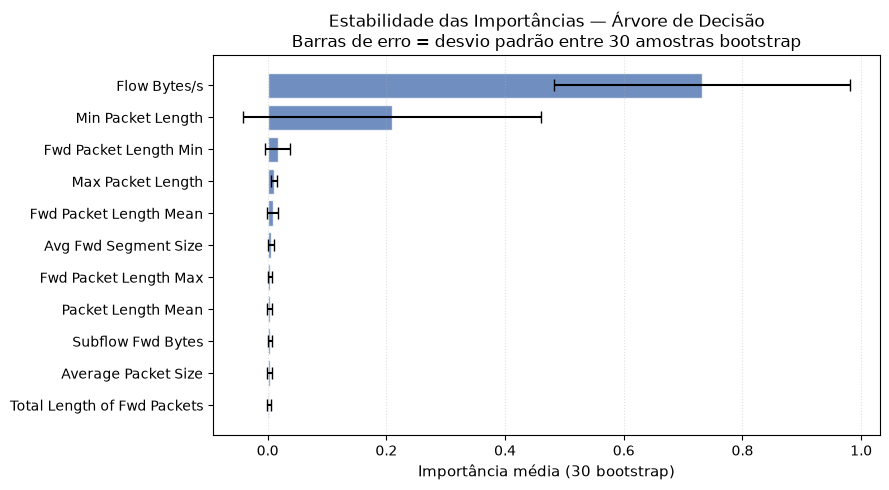


Coeficiente de variação por feature (menor = mais estável):
  Flow Bytes/s                        CV=0.340
  Max Packet Length                   CV=0.441
  Avg Fwd Segment Size                CV=0.827
  Fwd Packet Length Max               CV=1.012
  Subflow Fwd Bytes                   CV=1.073
  Fwd Packet Length Mean              CV=1.089
  Packet Length Mean                  CV=1.140
  Min Packet Length                   CV=1.196
  Fwd Packet Length Min               CV=1.263
  Average Packet Size                 CV=1.343
  Total Length of Fwd Packets         CV=1.492


In [60]:
from sklearn.utils import resample

# ── Garante que treina só nas features selecionadas ──
feature_names  = list(features)  # suas 9/10 features
X_train_sel    = np.array(X_train_res[feature_names])
y_train_np     = np.array(y_train_res)

n_boots = 30
importancias_boots = []

for i in range(n_boots):
    X_b, y_b = resample(X_train_sel, y_train_np, random_state=i)
    
    dt_b = DecisionTreeClassifier(
        criterion=best_dt.criterion,
        max_depth=best_dt.get_depth(),
        min_samples_leaf=best_dt.min_samples_leaf,
        random_state=42
    )
    dt_b.fit(X_b, y_b)
    importancias_boots.append(dt_b.feature_importances_)

importancias_boots = np.array(importancias_boots)
print(f"Shape: {importancias_boots.shape}")  # deve ser (30, 9) ou (30, 10)

# ── Média e desvio ──
media_imp = importancias_boots.mean(axis=0)
std_imp   = importancias_boots.std(axis=0)

imp_series = pd.Series(media_imp, index=feature_names).sort_values()
std_series = pd.Series(std_imp,   index=feature_names)[imp_series.index]

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [f.strip() for f in imp_series.index],
    imp_series.values,
    xerr=std_series.values,
    color='#4C72B0', alpha=0.8, capsize=4, edgecolor='white'
)
ax.set_xlabel('Importância média (30 bootstrap)', fontsize=11)
ax.set_title('Estabilidade das Importâncias — Árvore de Decisão\n'
             'Barras de erro = desvio padrão entre 30 amostras bootstrap', fontsize=12)
ax.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
# fig.savefig('./figures/estabilidade_dt.png', dpi=100, bbox_inches='tight')
plt.show()

# ── CV ──
cv_series = std_series / (imp_series.abs() + 1e-9)
print("\nCoeficiente de variação por feature (menor = mais estável):")
for feat, val in cv_series.sort_values().items():
    print(f"  {feat.strip():<35} CV={val:.3f}")

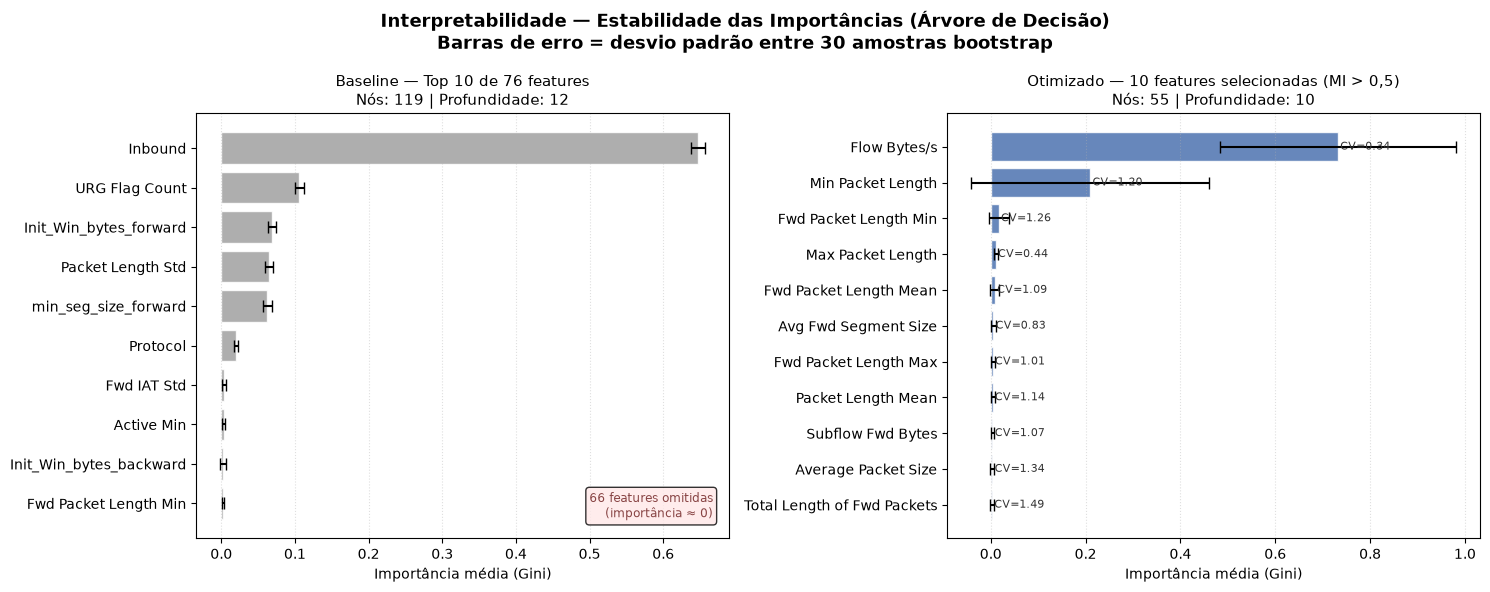


=== Coeficiente de Variação — Otimizado ===
(quanto menor, mais estável a explicação)

  Flow Bytes/s                        CV=0.340  ⚠️ moderado
  Max Packet Length                   CV=0.441  ⚠️ moderado
  Avg Fwd Segment Size                CV=0.827  ❌ instável
  Fwd Packet Length Max               CV=1.012  ❌ instável
  Subflow Fwd Bytes                   CV=1.073  ❌ instável
  Fwd Packet Length Mean              CV=1.089  ❌ instável
  Packet Length Mean                  CV=1.140  ❌ instável
  Min Packet Length                   CV=1.196  ❌ instável
  Fwd Packet Length Min               CV=1.263  ❌ instável
  Average Packet Size                 CV=1.343  ❌ instável
  Total Length of Fwd Packets         CV=1.492  ❌ instável


In [61]:
from sklearn.utils import resample

def bootstrap_importancias(X_train, y_train, modelo_ref, n_boots=30):
    """Calcula importâncias via bootstrap para qualquer DT."""
    X_np = np.array(X_train)
    y_np = np.array(y_train)
    boots = []
    for i in range(n_boots):
        X_b, y_b = resample(X_np, y_np, random_state=i)
        dt_b = DecisionTreeClassifier(
            criterion=modelo_ref.criterion,
            max_depth=modelo_ref.get_depth(),
            min_samples_leaf=modelo_ref.min_samples_leaf,
            random_state=42
        )
        dt_b.fit(X_b, y_b)
        boots.append(dt_b.feature_importances_)
    return np.array(boots)

# ── Baseline: 76 features, top 10 por importância ──
boots_base = bootstrap_importancias(X_train_base, y_train_base, dt_base)
media_base = boots_base.mean(axis=0)
std_base   = boots_base.std(axis=0)

# Pega só top 10 para caber no gráfico
feat_base_names = list(X_train_base.columns)
imp_base = pd.Series(media_base, index=feat_base_names)
std_base_s = pd.Series(std_base, index=feat_base_names)
top10      = imp_base.nlargest(10)
std_top10  = std_base_s[top10.index]

# ── Otimizado: 10 features selecionadas ──
feature_names = list(features)
boots_otim = bootstrap_importancias(
    X_train_res[feature_names], y_train_res, best_dt
)
media_otim = boots_otim.mean(axis=0)
std_otim   = boots_otim.std(axis=0)
imp_otim   = pd.Series(media_otim, index=feature_names).sort_values()
std_otim_s = pd.Series(std_otim,   index=feature_names)[imp_otim.index]

# ── Plot comparativo ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Interpretabilidade — Estabilidade das Importâncias (Árvore de Decisão)\n'
             'Barras de erro = desvio padrão entre 30 amostras bootstrap',
             fontsize=13, fontweight='bold')

# Painel esquerdo — Baseline (top 10 de 76)
ax = axes[0]
top10_sorted = top10.sort_values()
std_sorted   = std_top10[top10_sorted.index]
bars = ax.barh(
    [f.strip() for f in top10_sorted.index],
    top10_sorted.values,
    xerr=std_sorted.values,
    color='#A0A0A0', alpha=0.85, capsize=4, edgecolor='white'
)
ax.set_title(f'Baseline — Top 10 de 76 features\n'
             f'Nós: {dt_base.tree_.node_count} | Profundidade: {dt_base.get_depth()}',
             fontsize=11)
ax.set_xlabel('Importância média (Gini)', fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.annotate(f'66 features omitidas\n(importância ≈ 0)',
            xy=(0.97, 0.05), xycoords='axes fraction',
            ha='right', fontsize=8.5,
            color='#884444',
            bbox=dict(boxstyle='round,pad=0.3', fc='#FFE8E8', alpha=0.8))

# Painel direito — Otimizado (todas as 10 features)
ax = axes[1]
ax.barh(
    [f.strip() for f in imp_otim.index],
    imp_otim.values,
    xerr=std_otim_s.values,
    color='#4C72B0', alpha=0.85, capsize=4, edgecolor='white'
)
ax.set_title(f'Otimizado — 10 features selecionadas (MI > 0,5)\n'
             f'Nós: {best_dt.tree_.node_count} | Profundidade: {best_dt.get_depth()}',
             fontsize=11)
ax.set_xlabel('Importância média (Gini)', fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.4)

# CV no título de cada barra
cv_otim = std_otim_s / (imp_otim.abs() + 1e-9)
for i, (feat, val) in enumerate(imp_otim.items()):
    cv = cv_otim[feat]
    ax.text(val + 0.005, i, f'CV={cv:.2f}', va='center', fontsize=8, color='#333333')

plt.tight_layout()
# fig.savefig('./figures/interpretabilidade_estabilidade_comparativa.png',
            # dpi=100, bbox_inches='tight')
plt.show()

# ── Tabela de CV comparativa ──
print("\n=== Coeficiente de Variação — Otimizado ===")
print("(quanto menor, mais estável a explicação)\n")
for feat, val in cv_otim.sort_values().items():
    estab = "✅ estável" if val < 0.3 else ("⚠️ moderado" if val < 0.6 else "❌ instável")
    print(f"  {feat.strip():<35} CV={val:.3f}  {estab}")

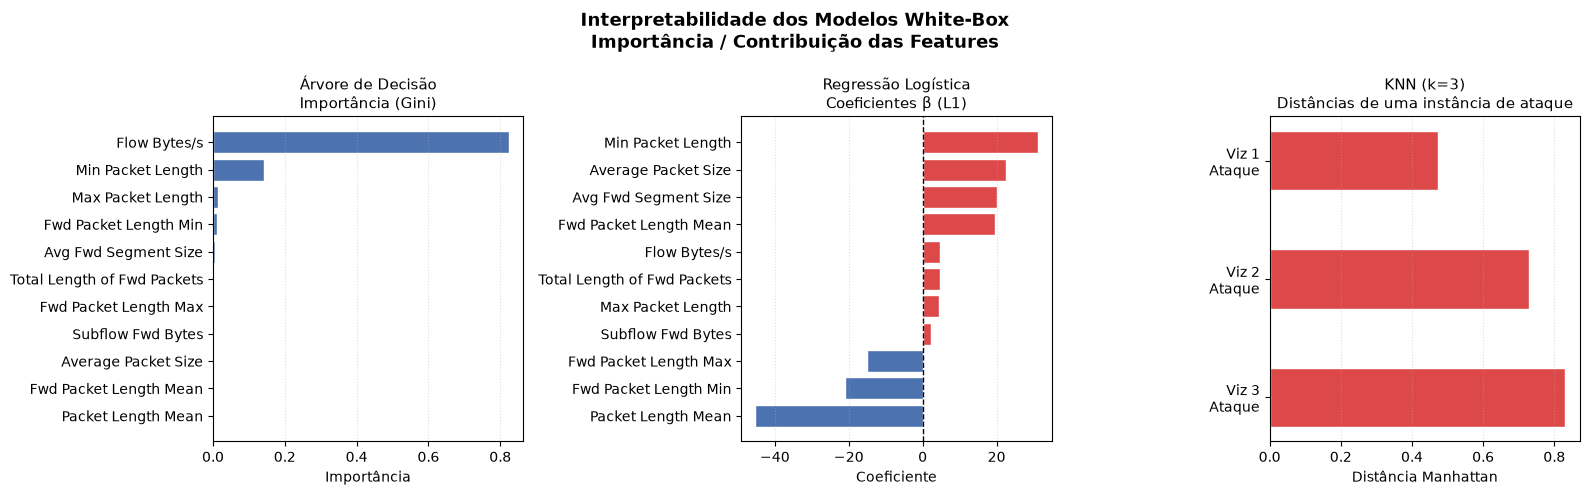

In [62]:
def achar_instancia_interessante(classe, X_test_np, X_train_np, 
                                  y_te_np, y_tr_np, modelo, n_candidatos=200):
    from sklearn.metrics import pairwise_distances
    candidatos = np.where(y_te_np == classe)[0][:n_candidatos]
    melhor_idx, melhor_score = None, -1
    
    for idx in candidatos:
        ponto = X_test_np[idx].reshape(1, -1)
        dists = pairwise_distances(ponto, X_train_np, metric=modelo.metric)[0]
        k = modelo.n_neighbors
        viz_dists = np.sort(dists)[:k]
        viz_cls   = y_tr_np[np.argsort(dists)[:k]]
        
        dist_var    = viz_dists.std()
        mix_classes = len(np.unique(viz_cls))
        score = dist_var * mix_classes
        
        if viz_dists.sum() > 0 and score > melhor_score:
            melhor_score = score
            melhor_idx   = idx
    
    return melhor_idx

# Agora chame o plot normalmente
idx = achar_instancia_interessante(
    1, np.array(X_test_scaled), np.array(X_train_scaled),
    np.array(y_test), np.array(y_train_res), best_knn
)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Interpretabilidade dos Modelos White-Box\n'
             'Importância / Contribuição das Features', 
             fontsize=13, fontweight='bold')

# DT — feature importances
ax = axes[0]
imp = best_dt.feature_importances_
ordem = np.argsort(imp)
ax.barh([features[i].strip() for i in ordem], 
        imp[ordem], color='#4C72B0', edgecolor='white')
ax.set_title('Árvore de Decisão\nImportância (Gini)', fontsize=11)
ax.set_xlabel('Importância', fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.4)

# LR — coeficientes
ax = axes[1]
coef_s = pd.Series(best_model.coef_[0], 
                    index=[f.strip() for f in features]).sort_values()
cores = ['#DD4949' if c > 0 else '#4C72B0' for c in coef_s]
ax.barh(coef_s.index, coef_s.values, color=cores, edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Regressão Logística\nCoeficientes β (L1)', fontsize=11)
ax.set_xlabel('Coeficiente', fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.4)

# KNN — análise de vizinhança de uma instância
ax = axes[2]

from sklearn.metrics import pairwise_distances
idx = achar_instancia_interessante(1, np.array(X_test_scaled), 
                                    np.array(X_train_scaled),
                                    np.array(y_test), np.array(y_train_res), best_knn)
ponto = np.array(X_test_scaled)[idx].reshape(1, -1)
dists = pairwise_distances(ponto, np.array(X_train_scaled), metric='manhattan')[0]
viz_idx   = np.argsort(dists)[:best_knn.n_neighbors]
viz_dists = dists[viz_idx]
viz_cls   = np.array(y_train_res)[viz_idx]

cores_viz = ['#DD4949' if c == 1 else '#4C72B0' for c in viz_cls]
labels_viz = [f'Viz {i+1}\n{"Ataque" if c==1 else "Benigno"}'
              for i, c in enumerate(viz_cls)]
ax.barh(labels_viz[::-1], viz_dists[::-1], 
        color=cores_viz[::-1], edgecolor='white', height=0.5)
ax.set_title(f'KNN (k={best_knn.n_neighbors})\nDistâncias de uma instância de ataque', 
             fontsize=11)
ax.set_xlabel('Distância Manhattan', fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
# fig.savefig('./figures/interpretabilidade_comparativa.png', dpi=100, bbox_inches='tight')
plt.show()

In [63]:
print("=== COMPLEXIDADE ESTRUTURAL ===\n")

# Árvore de Decisão
print("Árvore de Decisão:")
print(f"  Baseline  → Nós: {dt_base.tree_.node_count:>4} | Profundidade: {dt_base.get_depth():>2} | Folhas: {dt_base.get_n_leaves():>3} | Features: 76")
print(f"  Otimizado → Nós: {best_dt.tree_.node_count:>4} | Profundidade: {best_dt.get_depth():>2} | Folhas: {best_dt.get_n_leaves():>3} | Features: {len(features)}")

# Regressão Logística
coef_base_nz = (dt_base is not None)  # placeholder
coef_base  = np.abs(log_reg_base.coef_[0])
coef_otim  = np.abs(best_model.coef_[0])
print(f"\nRegressão Logística:")
print(f"  Baseline  → Coef não-zero: {(coef_base > 0).sum():>2} de 76 | Features: 76")
print(f"  Otimizado → Coef não-zero: {(coef_otim > 0).sum():>2} de {len(features)}  | Features: {len(features)}")

# KNN
print(f"\nKNN:")
print(f"  Baseline  → k={knn_base.n_neighbors}, métrica={knn_base.metric}, features=76")
print(f"  Otimizado → k={best_knn.n_neighbors}, métrica={best_knn.metric}, features={len(features)}")

=== COMPLEXIDADE ESTRUTURAL ===

Árvore de Decisão:
  Baseline  → Nós:  119 | Profundidade: 12 | Folhas:  60 | Features: 76
  Otimizado → Nós:   55 | Profundidade: 10 | Folhas:  28 | Features: 11

Regressão Logística:
  Baseline  → Coef não-zero: 67 de 76 | Features: 76
  Otimizado → Coef não-zero: 11 de 11  | Features: 11

KNN:
  Baseline  → k=5, métrica=minkowski, features=76
  Otimizado → k=3, métrica=manhattan, features=11


In [71]:
print("\n=== CONCENTRAÇÃO DA EXPLICAÇÃO (DT) ===\n")

def features_para_90(importancias, nomes):
    imp = pd.Series(importancias, index=nomes).sort_values(ascending=False)
    acum = imp.cumsum() / imp.sum()
    n = (acum <= 0.90).sum() + 1
    return n, imp.index[:n].tolist()

# Baseline
n_base, feats_base = features_para_90(dt_base.feature_importances_,
                                       list(X_train_base.columns))
# Otimizado
n_otim, feats_otim = features_para_90(best_dt.feature_importances_,
                                       list(features))

print(f"Baseline:  {n_base} features explicam 90% das decisões (de 76 possíveis)")
print(f"  → {feats_base}")
print(f"\nOtimizado: {n_otim} features explicam 90% das decisões (de {len(features)} possíveis)")
print(f"  → {feats_otim}")


=== CONCENTRAÇÃO DA EXPLICAÇÃO (DT) ===

Baseline:  5 features explicam 90% das decisões (de 76 possíveis)
  → ['Inbound', 'URG Flag Count', 'Packet Length Std', 'Init_Win_bytes_forward', 'min_seg_size_forward']

Otimizado: 2 features explicam 90% das decisões (de 11 possíveis)
  → ['Flow Bytes/s', 'Min Packet Length']


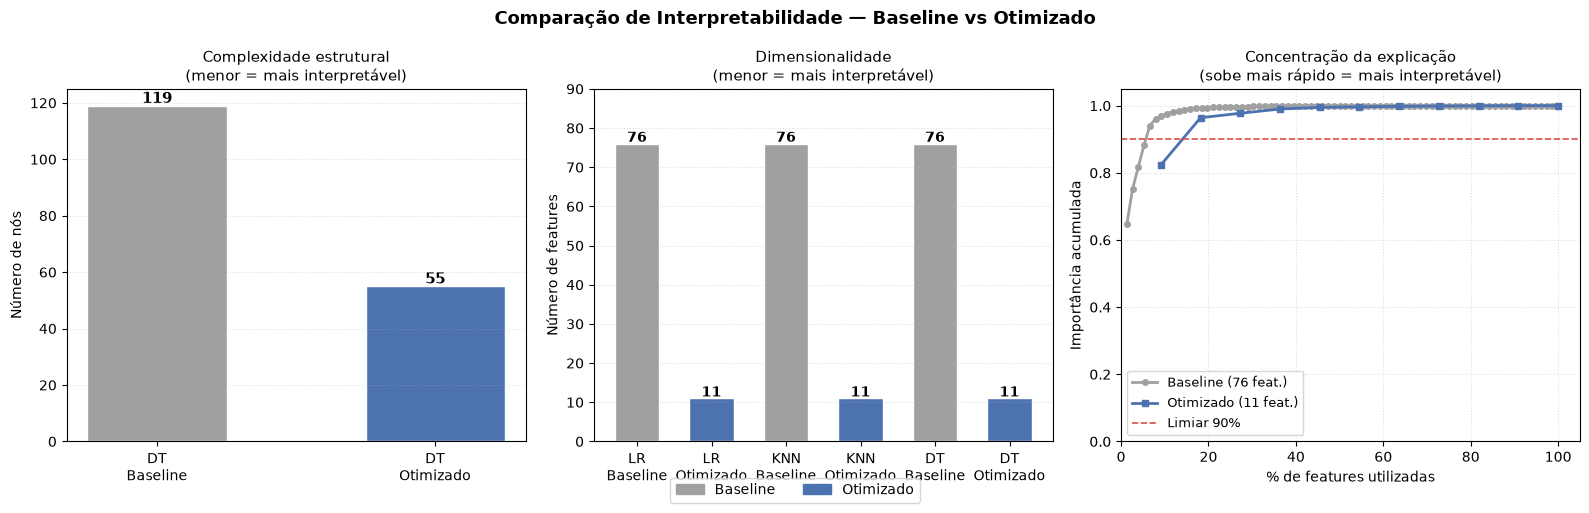

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparação de Interpretabilidade — Baseline vs Otimizado',
             fontsize=13, fontweight='bold')

# ── Painel 1: Complexidade (nós da DT) ──
ax = axes[0]
modelos   = ['DT\nBaseline', 'DT\nOtimizado']
nos       = [dt_base.tree_.node_count, best_dt.tree_.node_count]
cores_nos = ['#A0A0A0', '#4C72B0']
bars = ax.bar(modelos, nos, color=cores_nos, edgecolor='white', width=0.5)
for bar, val in zip(bars, nos):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de nós', fontsize=10)
ax.set_title('Complexidade estrutural\n(menor = mais interpretável)', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.4)

# ── Painel 2: Features usadas ──
ax = axes[1]
configs   = ['LR\nBaseline', 'LR\nOtimizado', 'KNN\nBaseline', 'KNN\nOtimizado', 'DT\nBaseline', 'DT\nOtimizado']
n_feats   = [76, len(features), 76, len(features), 76, len(features)]
cores_f   = ['#A0A0A0', '#4C72B0'] * 3
bars = ax.bar(configs, n_feats, color=cores_f, edgecolor='white', width=0.6)
for bar, val in zip(bars, n_feats):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Número de features', fontsize=10)
ax.set_title('Dimensionalidade\n(menor = mais interpretável)', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_ylim(0, 90)

# ── Painel 3: Concentração — curva de importância acumulada ──
ax = axes[2]

imp_base_sorted = pd.Series(
    dt_base.feature_importances_,
    index=list(X_train_base.columns)
).sort_values(ascending=False)

imp_otim_sorted = pd.Series(
    best_dt.feature_importances_,
    index=list(features)
).sort_values(ascending=False)

# Normaliza pelo número de features para comparar na mesma escala
x_base = np.arange(1, len(imp_base_sorted)+1) / len(imp_base_sorted) * 100
x_otim = np.arange(1, len(imp_otim_sorted)+1) / len(imp_otim_sorted) * 100

acum_base = imp_base_sorted.cumsum().values / imp_base_sorted.sum()
acum_otim = imp_otim_sorted.cumsum().values / imp_otim_sorted.sum()

ax.plot(x_base, acum_base, color='#A0A0A0', linewidth=2,
        marker='o', markersize=4, label=f'Baseline (76 feat.)')
ax.plot(x_otim, acum_otim, color='#4C72B0', linewidth=2,
        marker='s', markersize=5, label=f'Otimizado ({len(features)} feat.)')

ax.axhline(0.90, color='#DD4949', linewidth=1.2,
           linestyle='--', label='Limiar 90%')
ax.set_xlabel('% de features utilizadas', fontsize=10)
ax.set_ylabel('Importância acumulada', fontsize=10)
ax.set_title('Concentração da explicação\n(sobe mais rápido = mais interpretável)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.05)

# Legenda geral
from matplotlib.patches import Patch
leg_elements = [Patch(color='#A0A0A0', label='Baseline'),
                Patch(color='#4C72B0', label='Otimizado')]
fig.legend(handles=leg_elements, loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
fig.savefig('./comparacao_interpretabilidade.png',
            dpi=100, bbox_inches='tight')
plt.show()

In [73]:
imp_otim_sorted = pd.Series(
    best_dt.feature_importances_,
    index=list(features)
).sort_values(ascending=False)

acum = imp_otim_sorted.cumsum() / imp_otim_sorted.sum()
feats_90 = acum[acum <= 0.90].index.tolist() + [acum[acum > 0.90].index[0]]
print(f"Features que explicam 90% das decisões: {feats_90}")
print(f"Importâncias acumuladas:\n{acum}")

Features que explicam 90% das decisões: ['Flow Bytes/s', 'Min Packet Length']
Importâncias acumuladas:
Flow Bytes/s                   0.823130
Min Packet Length              0.964045
Max Packet Length              0.977394
Fwd Packet Length Min          0.989928
Avg Fwd Segment Size           0.995025
Total Length of Fwd Packets    0.996590
Fwd Packet Length Max          0.998027
Subflow Fwd Bytes              0.998853
Average Packet Size            0.999437
Fwd Packet Length Mean         1.000000
Packet Length Mean             1.000000
dtype: float64


## Testando validação de exemplos descartados

### Construindo base com os demais exemplos

In [44]:
#TODO COnstruir a base 
df_attack_unico = pd.read_csv('./data/attack_uniq.csv')

In [45]:
df_final_ataques = df_final[df_final['is_attack'] == 1]

In [46]:
df_val_externa = df_attack_unico.merge(df_final_ataques, how='left', indicator=True)
df_val_externa = df_val_externa[df_val_externa['_merge'] == 'left_only'].drop(columns='_merge')

print(f'attack_uniq total:        {len(df_attack_unico):,}')
print(f'Usados no final:          {len(df_final_ataques):,}')
print(f'Disponíveis p/ validação: {len(df_val_externa):,}')

attack_uniq total:        108,211
Usados no final:          20,000
Disponíveis p/ validação: 88,211


In [47]:
df_val_externa.to_csv('./data/validate.csv', index=False)

### Utilizando base sample attack

In [48]:
df_validate = pd.read_csv('./data/validate.csv')
df_validate.shape

(88211, 77)

Base para testar com o baseline

In [50]:
X_at_base = df_validate.drop(['is_attack'], axis=1)
y_at_base = df_validate['is_attack']

Base para testar nossa aplicação proposta

In [56]:
X_at = df_validate[features]
y_at = df_validate['is_attack']

#### BAseline

In [60]:
y_pred_lr_atk_base = log_reg_base.predict(X_at_base)
print(classification_report(y_at_base, y_pred_lr_atk_base))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.98      0.99     88211

    accuracy                           0.98     88211
   macro avg       0.50      0.49      0.50     88211
weighted avg       1.00      0.98      0.99     88211



/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


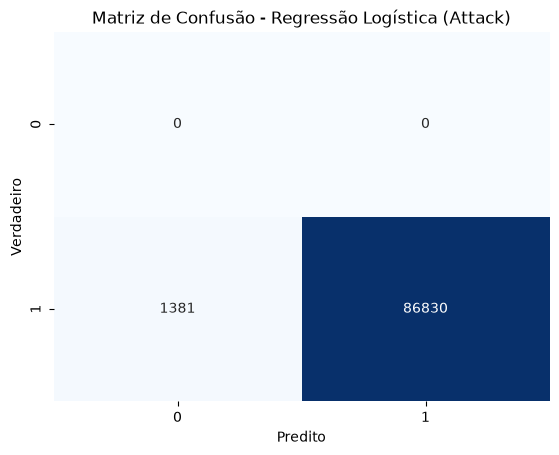

In [61]:
cm_lr_atk_base = confusion_matrix(y_at_base, y_pred_lr_atk_base)
sns.heatmap(cm_lr_atk_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Regressão Logística (Attack)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

In [62]:
y_pred_knn_atk_base = knn_base.predict(X_at_base)
print(classification_report(y_at, y_pred_knn_atk_base))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      1.00     88211

    accuracy                           0.99     88211
   macro avg       0.50      0.50      0.50     88211
weighted avg       1.00      0.99      1.00     88211



/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


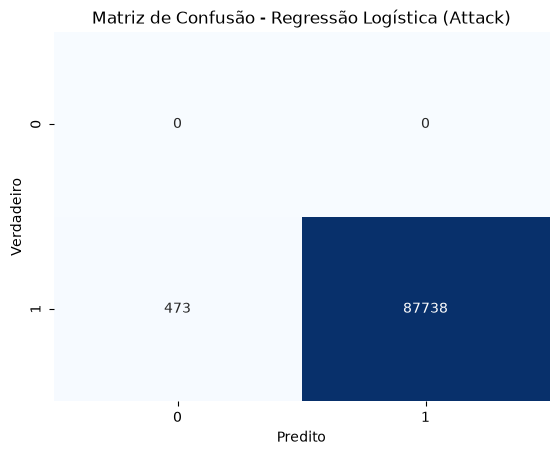

In [63]:
cm_knn_atk_base = confusion_matrix(y_at_base, y_pred_knn_atk_base)
sns.heatmap(cm_knn_atk_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Regressão Logística (Attack)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

In [64]:
y_pred_dt_atk_base = dt_base.predict(X_at_base)
print(classification_report(y_at, y_pred_dt_atk_base))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     88211

    accuracy                           1.00     88211
   macro avg       0.50      0.50      0.50     88211
weighted avg       1.00      1.00      1.00     88211



/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


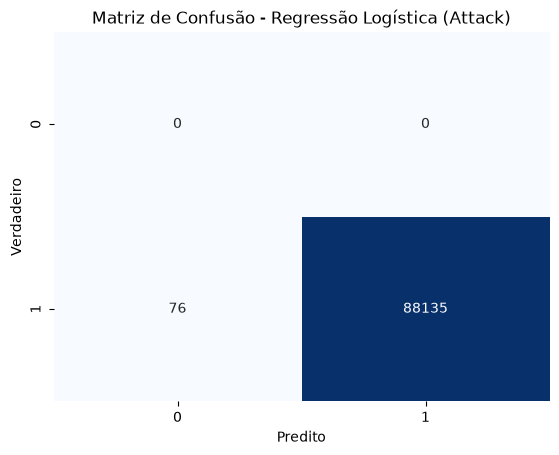

In [65]:
cm_dt_atk_base = confusion_matrix(y_at_base, y_pred_dt_atk_base)
sns.heatmap(cm_dt_atk_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Regressão Logística (Attack)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

#### **Aplicando nos nossos modelos**

In [88]:
y_pred_lr_atk = best_model.predict(X_at)
print(classification_report(y_at, y_pred_lr_atk))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     88211

    accuracy                           1.00     88211
   macro avg       0.50      0.50      0.50     88211
weighted avg       1.00      1.00      1.00     88211



/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/en

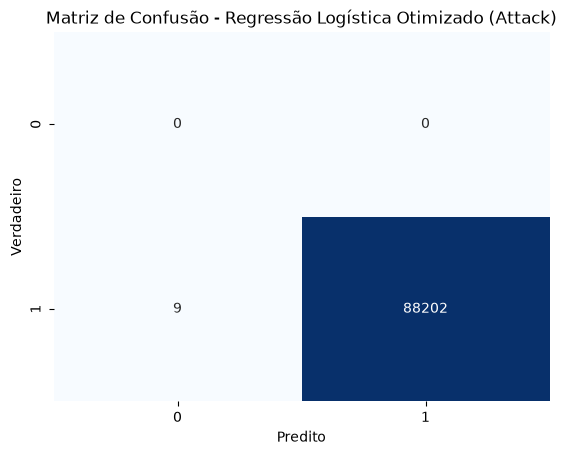

In [89]:
cm_lr_atk = confusion_matrix(y_at, y_pred_lr_atk)
sns.heatmap(cm_lr_atk, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Regressão Logística Otimizado (Attack)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

In [90]:
y_pred_knn_atk = best_knn.predict(X_at)
print(classification_report(y_at, y_pred_knn_atk))

/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     88211

    accuracy                           1.00     88211
   macro avg       0.50      0.50      0.50     88211
weighted avg       1.00      1.00      1.00     88211



/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


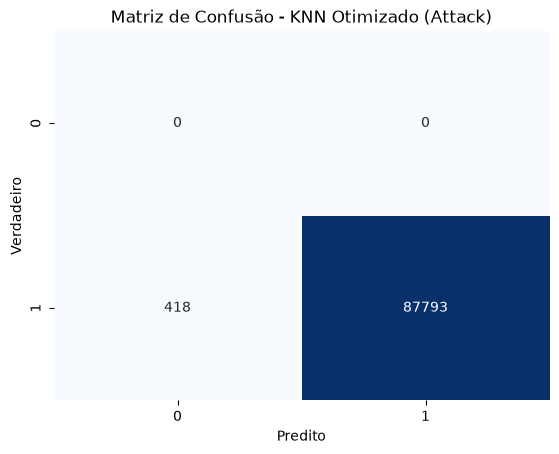

In [91]:
cm_knn_atk = confusion_matrix(y_at, y_pred_knn_atk)
sns.heatmap(cm_knn_atk, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - KNN Otimizado (Attack)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

In [78]:
y_pred_dt_atk = best_dt.predict(X_at)
print(classification_report(y_at, y_pred_dt_atk))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.98      0.99     88211

    accuracy                           0.98     88211
   macro avg       0.50      0.49      0.50     88211
weighted avg       1.00      0.98      0.99     88211



/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fernando/Documentos/rec-padroes/log-classifier/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


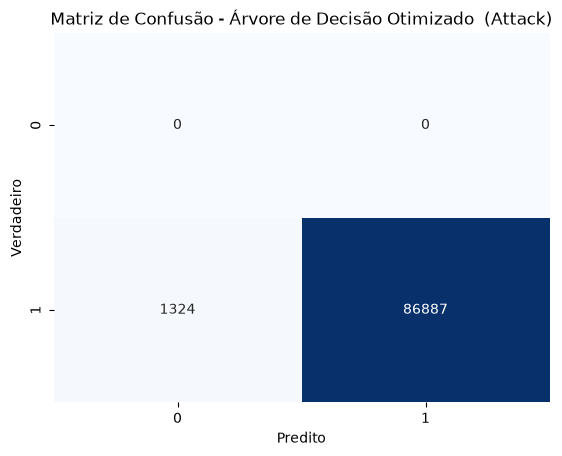

In [81]:
cm_dt_atk = confusion_matrix(y_at, y_pred_dt_atk)
sns.heatmap(cm_dt_atk, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Árvore de Decisão Otimizado  (Attack)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

#### Teste validação

In [93]:
from statsmodels.stats.contingency_tables import mcnemar

def teste_mcnemar(y_true, y_pred_a, y_pred_b, nome_a, nome_b):
    # Tabela de contingência: concordâncias e discordâncias
    # b = A acerta, B erra | c = A erra, B acerta
    b = ((y_pred_a == y_true) & (y_pred_b != y_true)).sum()
    c = ((y_pred_a != y_true) & (y_pred_b == y_true)).sum()
    
    tabela = [[0, b], [c, 0]]  # só b e c importam para McNemar
    resultado = mcnemar([[b+c, b], [c, 0]], exact=False, correction=True)
    
    print(f'{nome_a} vs {nome_b}:')
    print(f'  {nome_a} acerta, {nome_b} erra: {b}')
    print(f'  {nome_a} erra, {nome_b} acerta: {c}')
    print(f'  statistic={resultado.statistic:.4f}, p={resultado.pvalue:.4f}')
    print(f'  {"Diferença significativa ✅" if resultado.pvalue < 0.05 else "Sem diferença significativa ❌"}')
    print()

# Baseline vs Otimizado — por modelo
print("=== LR: Baseline vs Otimizado ===")
teste_mcnemar(y_at_base, y_pred_lr_atk_base, y_pred_lr_atk, 'LR Base', 'LR Otimizado')

print("=== KNN: Baseline vs Otimizado ===")
teste_mcnemar(y_at_base, y_pred_knn_atk_base, y_pred_knn_atk, 'KNN Base', 'KNN Otimizado')

print("=== DT: Baseline vs Otimizado ===")
teste_mcnemar(y_at_base, y_pred_dt_atk_base, y_pred_dt_atk, 'DT Base', 'DT Otimizado')

=== LR: Baseline vs Otimizado ===
LR Base vs LR Otimizado:
  LR Base acerta, LR Otimizado erra: 0
  LR Base erra, LR Otimizado acerta: 1372
  statistic=1370.0007, p=0.0000
  Diferença significativa ✅

=== KNN: Baseline vs Otimizado ===
KNN Base vs KNN Otimizado:
  KNN Base acerta, KNN Otimizado erra: 315
  KNN Base erra, KNN Otimizado acerta: 370
  statistic=4.2569, p=0.0391
  Diferença significativa ✅

=== DT: Baseline vs Otimizado ===
DT Base vs DT Otimizado:
  DT Base acerta, DT Otimizado erra: 1261
  DT Base erra, DT Otimizado acerta: 13
  statistic=1220.5722, p=0.0000
  Diferença significativa ✅

